In [53]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np


In [54]:
from faker import Faker
import random
import pandas as pd

fake = Faker()
data = []

product_categories = ['Electronics', 'Clothing', 'Books', 'Home', 'Sports']

for _ in range(500):
    data.append({
        "Order_id": fake.uuid4(),
        "Order_date": fake.date(),
        "Customer_id": fake.random_int(min=1000, max=9999),
        "Product_category": random.choice(product_categories),
        "Price": fake.random_int(min=500, max=50000),
        "Quantity": fake.random_int(min=1, max=10),
        "Discount_percent": fake.random_int(min=0, max=50)
    })

df = pd.DataFrame(data)
df.to_csv('E-commerce.csv', index=False)
print(df.head())

                               Order_id  Order_date  Customer_id  \
0  e8670d1a-5f1f-4535-80cb-e1847589ad4c  2007-01-25         9897   
1  78d38c4b-e147-4293-8c19-d47d9353e8d0  1992-09-28         7340   
2  965c5b08-cb94-4b43-b359-b296a6338ffe  2011-04-30         8716   
3  b59641cd-6811-4177-98e1-524e3ad1f0a4  1979-05-06         9127   
4  05efa81e-cd67-4ac6-a64b-06a3f4681c81  2013-12-25         5576   

  Product_category  Price  Quantity  Discount_percent  
0            Books  30115         6                 3  
1             Home  25742         4                45  
2         Clothing   9448         7                37  
3             Home  29822         8                 6  
4            Books  46007         1                28  


In [55]:
df['final_amount']=df['Price']*df['Quantity']*(1-df['Discount_percent']/100)
df.head()

,Order_id,Order_date,Customer_id,Product_category,Price,Quantity,Discount_percent,final_amount
0,e8670d1a-5f1f-4535-80cb-e1847589ad4c,2007-01-25,9897,Books,30115,6,3,175269.30
1,78d38c4b-e147-4293-8c19-d47d9353e8d0,1992-09-28,7340,Home,25742,4,45,56632.40
2,965c5b08-cb94-4b43-b359-b296a6338ffe,2011-04-30,8716,Clothing,9448,7,37,41665.68
3,b59641cd-6811-4177-98e1-524e3ad1f0a4,1979-05-06,9127,Home,29822,8,6,224261.44
4,05efa81e-cd67-4ac6-a64b-06a3f4681c81,2013-12-25,5576,Books,46007,1,28,33125.04


In [56]:
monthly_revenue=df.groupby('Product_category')['final_amount'].sum()
monthly_revenue

Product_category
Books          12426720.82
Clothing       10550990.67
Electronics    10638849.60
Home           11746233.77
Sports          8256603.79
Name: final_amount, dtype: float64

In [57]:
top3=df.groupby('Product_category')['final_amount'].sum().sort_values(ascending=False)
df.head(3)

,Order_id,Order_date,Customer_id,Product_category,Price,Quantity,Discount_percent,final_amount
0,e8670d1a-5f1f-4535-80cb-e1847589ad4c,2007-01-25,9897,Books,30115,6,3,175269.30
1,78d38c4b-e147-4293-8c19-d47d9353e8d0,1992-09-28,7340,Home,25742,4,45,56632.40
2,965c5b08-cb94-4b43-b359-b296a6338ffe,2011-04-30,8716,Clothing,9448,7,37,41665.68


In [58]:
# calculate outliers
mean=np.mean(df['final_amount'])
std=np.std(df['final_amount'])
df['z_score']=(df['final_amount']-mean)/std

In [59]:
out=df[np.abs(df['z_score'])>3]
out

,Order_id,Order_date,Customer_id,Product_category,Price,Quantity,Discount_percent,final_amount,z_score
46,b62f543d-d913-49bb-becc-c5e4dc5082d6,2013-01-26,4449,Clothing,44857,10,1,444084.3,3.593010
179,23c5f78f-5d08-4f4f-83d7-d13efcc2c224,2003-08-31,9148,Books,46667,10,11,415336.3,3.286365
353,14c656bd-d5f5-4bf7-a493-d99b0f05cda6,1985-08-31,6192,Clothing,49744,10,3,482516.8,4.002955
368,fb360203-139f-463a-9410-3d676fee9515,2025-12-31,9694,Electronics,43915,10,1,434758.5,3.493535
378,851dc755-7db2-4969-aef7-66cdc4873d1c,2024-01-28,4121,Books,45056,9,0,405504.0,3.181487


In [66]:
median=np.median(df['final_amount'])
df['final_amount']=np.where((df['z_score']>3),median,df['final_amount'])
df.head(3)

,Order_id,Order_date,Customer_id,Product_category,Price,Quantity,Discount_percent,final_amount,z_score,month
0,e8670d1a-5f1f-4535-80cb-e1847589ad4c,2007-01-25,9897,Books,30115,6,3,175269.30,0.725657,2007-01
1,78d38c4b-e147-4293-8c19-d47d9353e8d0,1992-09-28,7340,Home,25742,4,45,56632.40,-0.539800,1992-09
2,965c5b08-cb94-4b43-b359-b296a6338ffe,2011-04-30,8716,Clothing,9448,7,37,41665.68,-0.699445,2011-04


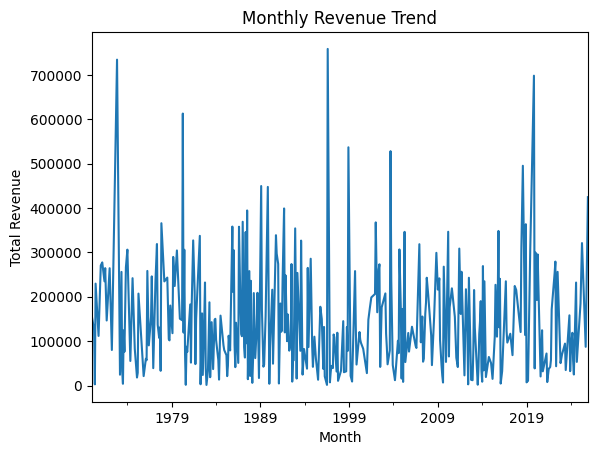

In [67]:
df['Order_date'] = pd.to_datetime(df['Order_date'])
df['month'] = df['Order_date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['final_amount'].sum()

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

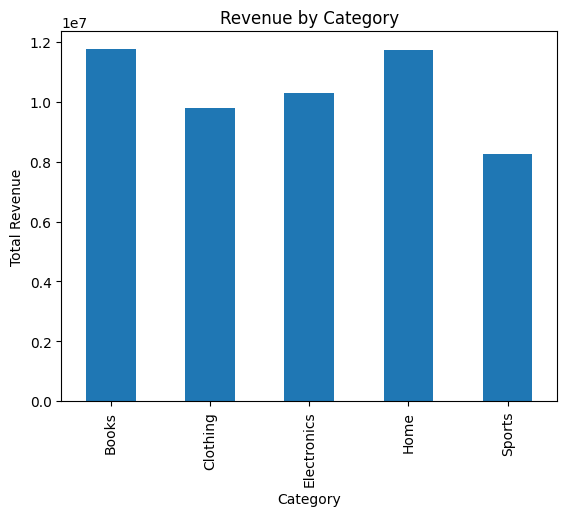

In [69]:
df.groupby('Product_category')['final_amount'].sum().plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.show()